# 🚕 Taxi Dataset Exploratory Data Analysis (EDA)

This notebook explores the NYC Taxi dataset using PySpark.

### Goals:
- Understand dataset structure
- Check missing values
- Analyze distributions
- Visualize key relationships (distance vs fare, trips by hour)

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Taxi EDA") \
    .getOrCreate()

26/05/17 00:22:09 WARN Utils: Your hostname, DESKTOP-MI38V86 resolves to a loopback address: 127.0.1.1; using 172.18.94.27 instead (on interface eth0)
26/05/17 00:22:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/17 00:22:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, count, when, hour

## 📂 Load Dataset

We load the raw parquet file and inspect its structure.

In [3]:
df = spark.read.parquet("../data/taxi.parquet")

df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       2| 2025-02-01 00:12:18|  2025-02-01 00:32:33|              3|         3.12|         1|                 N|         246|    

## 📊 Dataset Overview

We inspect schema and size to understand data scale and structure before preprocessing.

In [4]:
print("Rows:", df.count())
print("Columns:", len(df.columns))
df.printSchema()

Rows: 3577543
Columns: 20
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



## 📈 Statistical Summary

We inspect numerical statistics such as mean, minimum,
maximum, and standard deviation to better understand
the dataset distribution.

In [5]:
df.describe().show()

26/05/17 00:22:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+------------------+------------------+---------------------+------------------+--------------------+-------------------+------------------+
|summary|          VendorID|   passenger_count|    trip_distance|        RatecodeID|store_and_fwd_flag|      PULocationID|      DOLocationID|      payment_type|      fare_amount|             extra|            mta_tax|        tip_amount|      tolls_amount|improvement_surcharge|      total_amount|congestion_surcharge|        Airport_fee|cbd_congestion_fee|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+------------------+------------------+---------------------+---------

## ❓ Missing Values Check

We count missing values in each column.

In [6]:

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       0|                   0|                    0|         806937|            0|    806937|            806937|           0|    

## 📉 Sampling for Visualization

Since Spark DataFrames can be very large,
we convert only a sample of the data to Pandas
for efficient visualization.

In [7]:
pdf = df.sample(False, 0.01, seed=42).limit(5000).toPandas()

## 💰 Fare Amount Distribution

We visualize the distribution of taxi fares to detect
skewness and potential outliers.

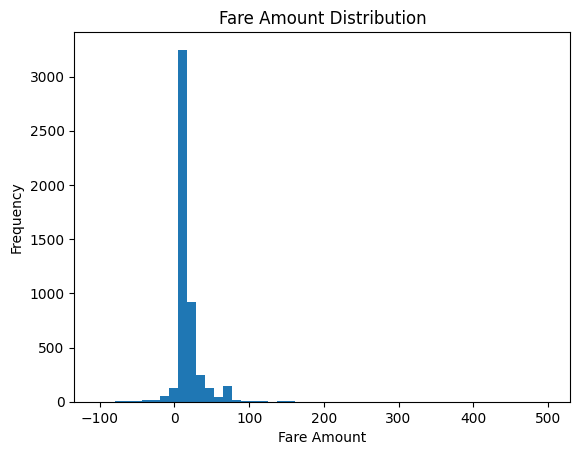

In [8]:
plt.hist(pdf["fare_amount"], bins=50)
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.title("Fare Amount Distribution")
plt.show()

### Insight
Most fares are concentrated in a lower range, with few high-value trips (right-skewed distribution).

## 📦 Fare Amount Outliers

We use a boxplot to identify extreme fare values
that may affect model performance.

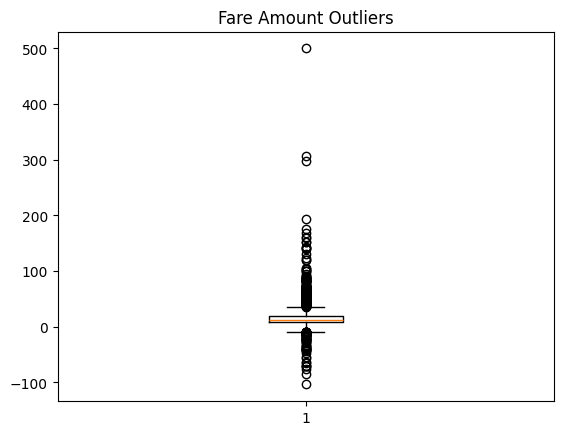

In [9]:
plt.boxplot(pdf["fare_amount"])
plt.title("Fare Amount Outliers")
plt.show()

## 📊 Distance vs Fare Relationship

We visualize how trip distance affects fare amount.

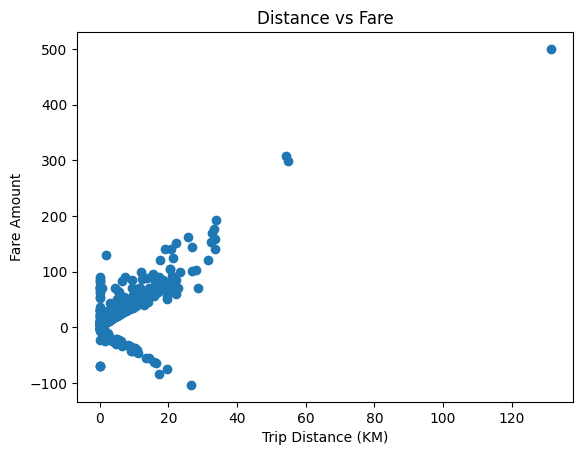

In [10]:

plt.scatter(pdf["trip_distance"], pdf["fare_amount"])
plt.xlabel("Trip Distance (KM)")
plt.ylabel("Fare Amount")
plt.title("Distance vs Fare")
plt.show()

## 💵 Tip Amount Analysis
We analyze distribution of tip amounts.

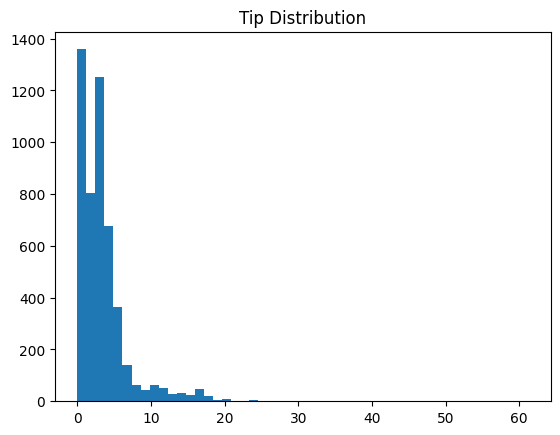

In [11]:
plt.hist(pdf["tip_amount"], bins=50)
plt.title("Tip Distribution")
plt.show()

## 👥 Passenger Count Analysis
We analyze distribution of passengers per trip.

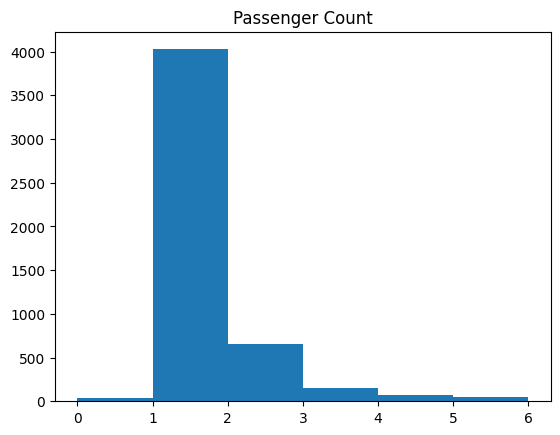

In [12]:
plt.hist(pdf["passenger_count"], bins=6)
plt.title("Passenger Count")
plt.show()

## 🕒 Trips by Hour
We analyze taxi demand across different hours.

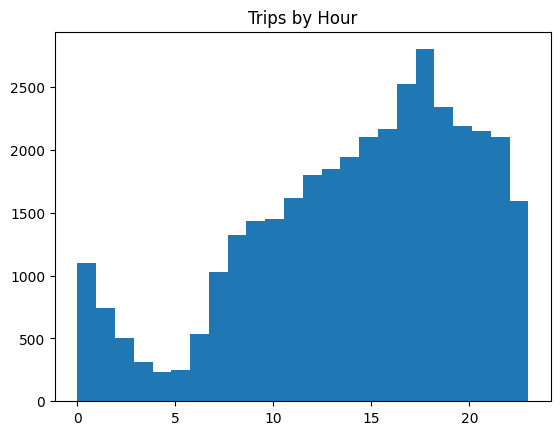

In [13]:
from pyspark.sql.functions import hour

hour_df = df.withColumn("hour", hour("tpep_pickup_datetime"))
hour_pdf = hour_df.select("hour").sample(False, 0.01, seed=42).toPandas()

plt.hist(hour_pdf["hour"], bins=24)
plt.title("Trips by Hour")
plt.show()

### Insight
Trips are concentrated during peak hours, indicating strong time-based demand patterns.

## 🔗 Correlation Analysis

We analyze correlations between numerical features
to understand relationships in the dataset.

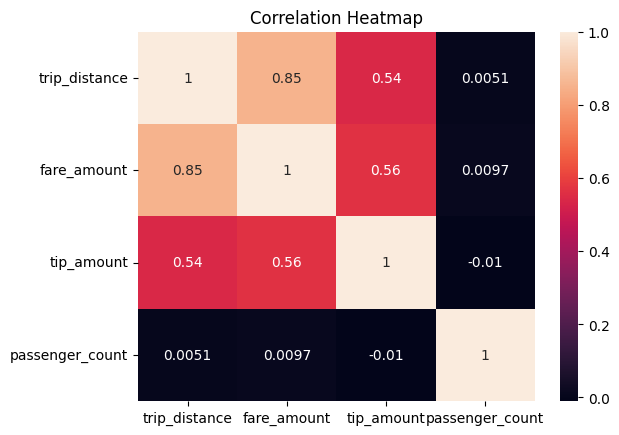

In [14]:
import seaborn as sns

corr = pdf[[
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "passenger_count"
]].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Insight
- Distance has the strongest correlation with fare and total amount.
- Tip amount has weak correlation with fare.
- Passenger count has minimal effect on pricing.

## 💰 Fare vs Total Amount
We compare base fare with total payment.

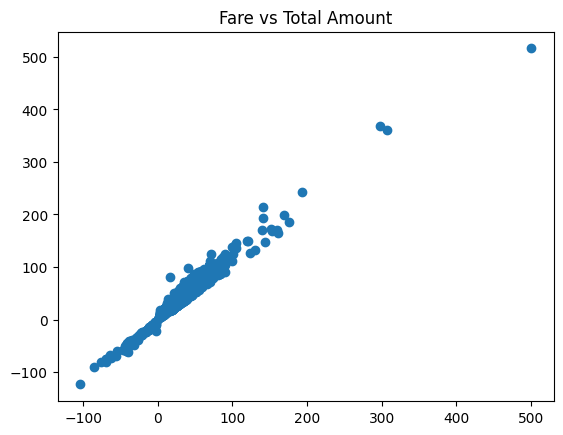

In [15]:
plt.scatter(pdf["fare_amount"], pdf["total_amount"])
plt.title("Fare vs Total Amount")
plt.show()

## 📌 Final Insights

- Fare increases with distance
- Tips vary significantly
- Peak demand occurs during specific hours
- Passenger count has limited effect on fare
- Total amount includes multiple fees beyond fare